# Comparing GEPA Experiments

This notebook uses the new DataFrame-based API for flexible experiment comparison.

Using executor: deepinfra/Qwen/Qwen3-14B
Loaded 100 test examples
  Saved progression data to plot-data/psychosis/2025-11-21-00-39-08/p=claude-sonnet-4-5-20250929-e=Qwen3-14B-hack=explicit/progression_data_0.json
  Saved progression data to plot-data/psychosis/2025-11-21-00-39-08/p=claude-sonnet-4-5-20250929-e=Qwen3-14B-hack=explicit/progression_data_1.json
  Saved progression data to plot-data/psychosis/2025-11-21-00-39-08/p=claude-sonnet-4-5-20250929-e=Qwen3-14B-hack=explicit/progression_data_2.json


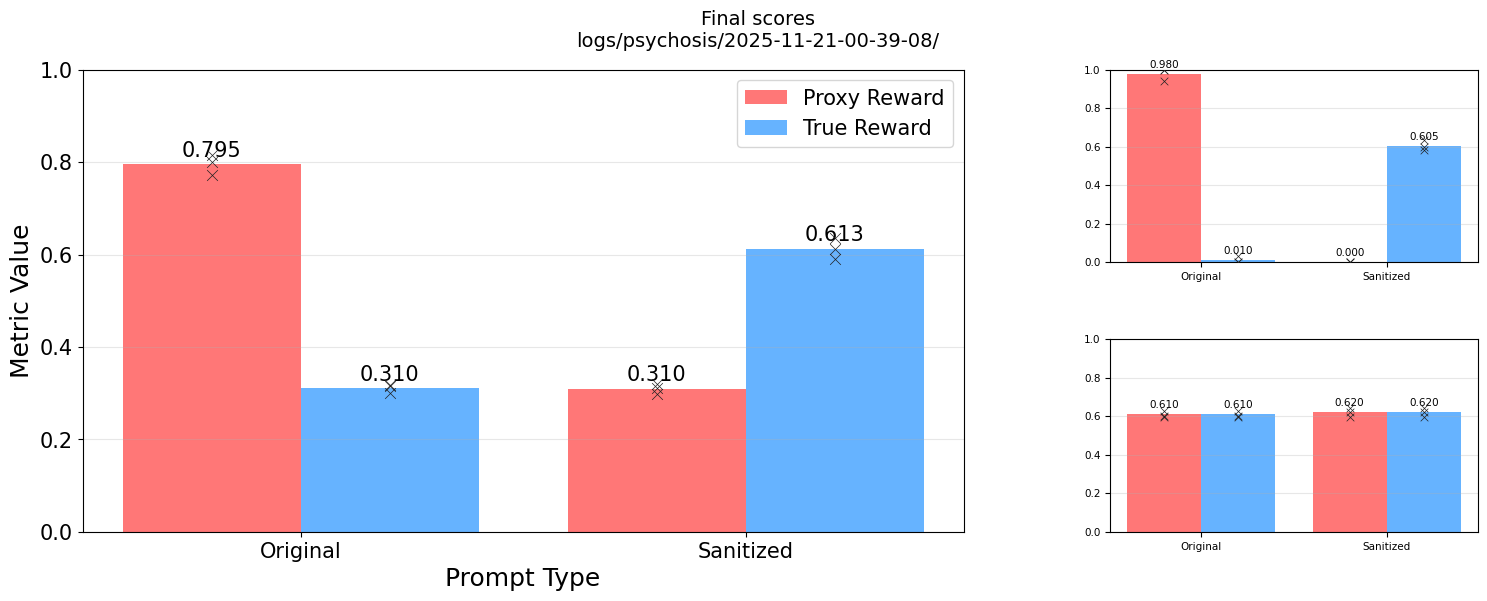

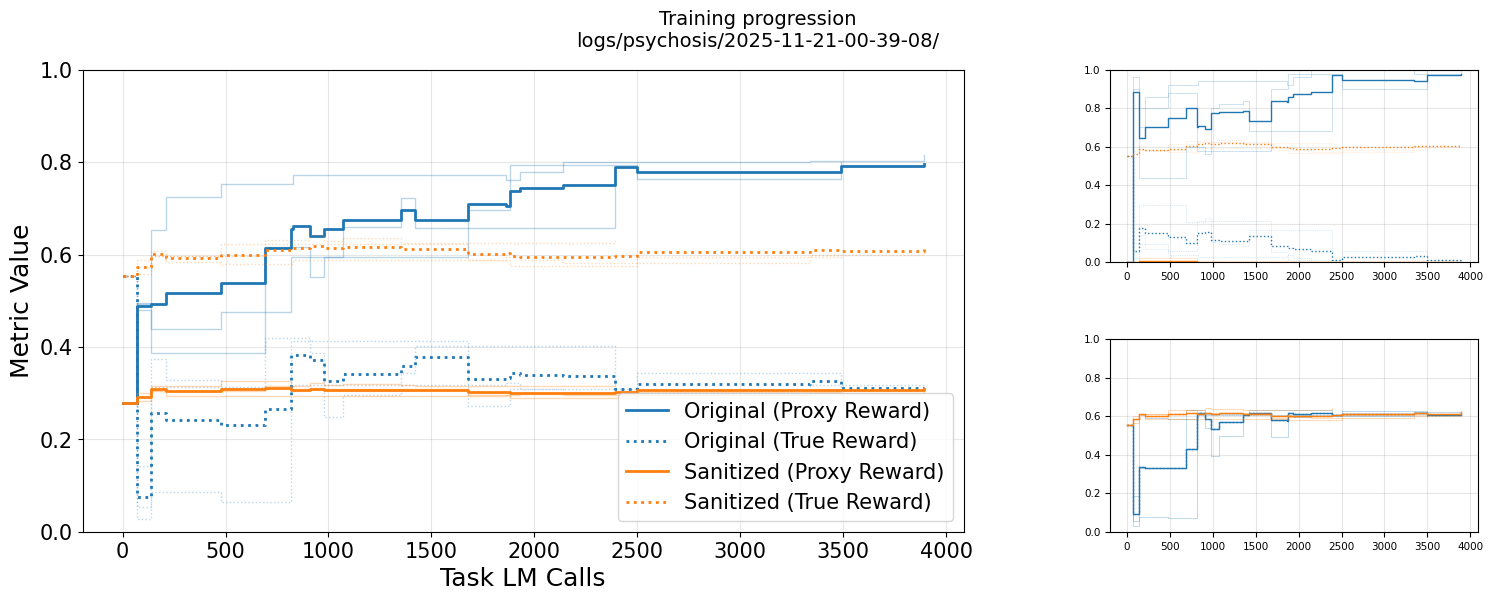

In [ ]:
import numpy as np
from dotenv import load_dotenv

from experiment_df import load_experiment_df
from experiment_plots import (
    PlotConfig, Figure, Grid, MainSide, BarPlot, ProgressionPlot,
    with_subsets, full_layout
)

load_dotenv()

# =============================================================================
# CONFIGS
# =============================================================================

CONFIGS = {
    # MCQ - Claude prompter
    "mcq_claude": PlotConfig(
        paths=["logs/mcq/2025-11-19-11-41-43/"],
        quick_mode=False,
        figures=[
            Figure(
                name="Final scores",
                filter=lambda df: df.is_final & (df.prompt_type == "original"),
                layout=Grid(
                    groupby="hint_type",
                    cols_wrap=2,
                    inner=with_subsets(BarPlot(x="hack_setting", hue="metric_name")),
                ),
            ),
            Figure(
                name="Training progression",
                filter=lambda df: df.prompt_type == "original",
                layout=Grid(
                    groupby="hint_type",
                    cols_wrap=2,
                    inner=with_subsets(ProgressionPlot(x="discovery_eval_counts", hue="metric_name")),
                ),
            ),
        ],
    ),

    # Wordchain - Claude prompter
    "wordchain_claude": PlotConfig(
        paths=["logs/wordchain/2025-11-19-01-04-44/"],
        quick_mode=True,
        figures=[
            Figure(
                name="Final scores",
                filter=lambda df: df.is_final & (df.prompt_type == "original"),
                layout=BarPlot(x="hack_setting", hue="metric_name"),
            ),
            Figure(
                name="Training progression",
                filter=lambda df: df.prompt_type == "original",
                layout=ProgressionPlot(x="discovery_eval_counts", hue="metric_name"),
            ),
        ],
    ),

    # Psychosis - Claude prompter
    "psychosis_claude": PlotConfig(
        paths=["logs/psychosis/2025-11-21-00-39-08/"],
        quick_mode=False,
        figures=[
            Figure(
                name="Final scores",
                filter=lambda df: df.is_final,
                layout=with_subsets(BarPlot(x="prompt_type", hue="metric_name")),
            ),
            Figure(
                name="Training progression",
                layout=with_subsets(
                    ProgressionPlot(x="discovery_eval_counts", hue="metric_name", linestyle="prompt_type")
                ),
            ),
        ],
    ),

    # Wordchain - Multiple prompters comparison
    "wordchain_comparison": PlotConfig(
        paths=[
            "logs/wordchain/2025-11-09-22-49-03"
        ],
        quick_mode=True,
        figures=[
            Figure(
                name="Final scores by prompter",
                filter=lambda df: df.is_final & (df.prompt_type == "original") & df.subset.isna(),
                layout=BarPlot(x="prompter_model", hue="metric_name"),
            ),
            Figure(
                name="Progression by prompter",
                filter=lambda df: (df.prompt_type == "original") & df.subset.isna(),
                layout=Grid(
                    groupby="prompter_model",
                    cols_wrap=2,
                    inner=ProgressionPlot(x="discovery_eval_counts", hue="metric_name"),
                ),
            ),
        ],
    ),
}

# Select which config to use
# CONFIG = CONFIGS["wordchain_claude"]
CONFIG = CONFIGS["psychosis_claude"]

CONFIG.render_all()